# 🏗️ Notebook 1: Point Cloud Morphing GNN — *The Architect*

**Pipeline Role:** Given a desired formation ID and the number of drones N, this model generates an
ideal set of N target *slots* (positions) that form the requested shape.

### Key Design Decisions
| Choice | Reason |
|---|---|
| **Dummy-shape seed** (uniform circle) | Translation-invariant — the seed carries no absolute position |
| **Displacement output** | Network learns *offsets* from the seed, not raw coordinates → easier to train |
| **Chamfer Distance loss** | Order-invariant set loss — no permutation matching needed |
| **Formation Embedding broadcast** | One global style code injected into every node |

### V6 Dataset Integration
- **Data source:** `architect_dataset_10k_V3.pt` generated by `data_generation_v6.ipynb`
- **Formations:** A (0), V (1), W (2), O (3), Rectangle (4), Triangle (5) — **6 formations**
- **Swarm sizes:** N = 5 – 30 (scale-adaptive, corners-first, collision-safe)
- **Removed:** old hand-written samplers (square, triangle, letter-L, circle) — replaced by V6 data


## 0. Install Dependencies

In [27]:
# # ── Install PyTorch Geometric (CPU build for portability) ──────────────────────
# # If you're on GPU, replace the torch-scatter / torch-sparse URLs with the
# # appropriate CUDA variant from https://data.pyg.org/whl/
# import sys

# !{sys.executable} -m pip install torch torchvision --quiet
# !{sys.executable} -m pip install torch_geometric --quiet
# # Sparse / scatter ops needed by PyG
# !{sys.executable} -m pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.2.0+cpu.html --quiet
# !{sys.executable} -m pip install matplotlib scipy --quiet

# print("✅ Dependencies installed")

## 1. Imports & Reproducibility

In [28]:
# ── Standard library ────────────────────────────────────────────────────────────
import math
import random
from typing import List, Tuple, Dict

# ── Numerical / Viz ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── PyTorch ──────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

# ── PyTorch Geometric ────────────────────────────────────────────────────────────
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GATv2Conv
from torch_geometric.transforms import KNNGraph        # builds k-NN edge_index

# ── Reproducibility ─────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Hyper-parameters

In [29]:
# ── Model ────────────────────────────────────────────────────────────────────────
FORMATION_EMB_DIM = 16    # size of the learned formation-ID embedding
HIDDEN_DIM        = 64    # hidden channel width in GATv2 layers
NUM_GAT_HEADS     = 4     # multi-head attention heads per layer
NUM_GNN_LAYERS    = 3     # depth of the GNN stack
K_NEIGHBORS       = 5     # k in the k-NN seed graph

# ── Data / Training ──────────────────────────────────────────────────────────────
# V6 dataset: 6 formations (A, V, W, O, Rectangle, Triangle), N = 5–30
NUM_FORMATIONS = 6
N_DRONES_RANGE = (5, 30)

BATCH_SIZE        = 16
NUM_EPOCHS        = 300
LR                = 1e-3
SEED_CIRCLE_RADIUS = 1.0

# Path to the pre-generated V6 dataset file
DATASET_PATH = './dataset/architect_dataset_10k_V10.pt'

# Formation registry — must match data_generation_v6.ipynb exactly
FORMATION_IDS = {'A': 0, 'V': 1, 'W': 2, 'O': 3, 'RECTANGLE': 4, 'TRIANGLE': 5}
ID_TO_NAME    = {v: k for k, v in FORMATION_IDS.items()}

# Node feature dimensionality:
#   seed_pos (2) + formation_emb (16) + n_normalised (1) + node_idx_norm (1) = 20
NODE_FEAT_DIM = 2 + FORMATION_EMB_DIM + 2  # → 20

# ── Separation-penalty loss ───────────────────────────────────────────────────────
# Weight of the separation penalty relative to Chamfer Distance.
# Total loss = chamfer_distance + SEP_LAMBDA * separation_penalty
#
# Tuning guide:
#   SEP_LAMBDA = 0.0   → pure Chamfer (original behaviour, may produce overlaps)
#   SEP_LAMBDA = 0.05  → gentle nudge, usually enough to fix clustering
#   SEP_LAMBDA = 0.2   → strong separation; increase if overlaps persist after 100 epochs
#   SEP_LAMBDA > 0.5   → risk of over-spreading: model pushes points apart more
#                        than it tries to match the formation shape
SEP_LAMBDA   = 0.1  # gentle nudge — GT already guarantees ≥0.5 separation

# Minimum desired distance between any two predicted slots.
# Must match the MIN_DRONE_DIST used in data_generation_v6.ipynb (= 0.30).
# The penalty activates only for pairs closer than this — pairs already
# further apart contribute zero gradient.
MIN_PRED_DIST = 0.5

## 3. Formation Registry

The V6 data generation pipeline defines 6 formations with scale-adaptive, corners-first placement
and a `MIN_DRONE_DIST = 0.30` collision-safety guarantee. We simply declare the mapping here —
no hand-written samplers needed. The ground-truth point clouds are loaded directly from the `.pt` file.


Loading dataset from: ./dataset/architect_dataset_10k_V10.pt
  Loaded 10000 samples


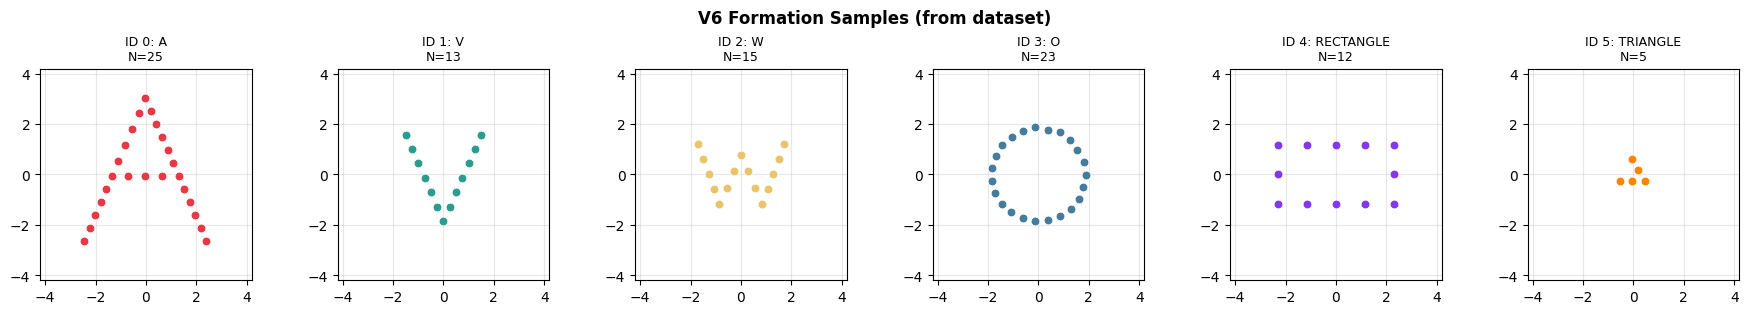

  edge_attr shape per sample: torch.Size([134, 2])  ✅


In [30]:
# Formation registry — mirrors data_generation_v6.ipynb
# No hand-written samplers: ground-truth comes from the pre-generated dataset.

FORMATION_NAMES = ID_TO_NAME  # alias for backward compat with any downstream code

# ── Quick preview: load dataset and visualise one sample per formation ────────────
print(f"Loading dataset from: {DATASET_PATH}")
_preview_ds = torch.load(DATASET_PATH, weights_only=False)
print(f"  Loaded {len(_preview_ds)} samples")

# Collect one representative sample per formation for the preview grid
_preview_map = {}
for _d in _preview_ds:
    _fid = int(_d.formation_id.item())
    if _fid not in _preview_map:
        _preview_map[_fid] = _d
    if len(_preview_map) == NUM_FORMATIONS:
        break

_COLOURS = {0:'#E63946', 1:'#2A9D8F', 2:'#E9C46A', 3:'#457B9D', 4:'#8338EC', 5:'#FB8500'}

fig, axes = plt.subplots(1, NUM_FORMATIONS, figsize=(18, 3))
for _fid in range(NUM_FORMATIONS):
    ax   = axes[_fid]
    _d   = _preview_map.get(_fid)
    if _d is None:
        ax.set_visible(False); continue
    pts  = _d.y.numpy()
    n    = int(_d.n_drones.item())
    col  = _COLOURS[_fid]
    ax.scatter(pts[:, 0], pts[:, 1], c=col, s=40, edgecolors='white', linewidths=0.6, zorder=3)
    ax.set_title(f"ID {_fid}: {ID_TO_NAME[_fid]}\nN={n}", fontsize=9)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    # Fixed shared axis so sizes are comparable
    ax.set_xlim(-4.2, 4.2); ax.set_ylim(-4.2, 4.2)
plt.suptitle("V6 Formation Samples (from dataset)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
# Verify edge_attr is present in the loaded dataset
_sample0 = _preview_map[0]
assert hasattr(_sample0, 'edge_attr') and _sample0.edge_attr is not None, (
    'edge_attr is None in the dataset. '
    'Regenerate using data_generation_v6.ipynb which computes '
    'edge_attr = seed_pos[dst] - seed_pos[src] after KNNGraph.'
)
print(f'  edge_attr shape per sample: {_sample0.edge_attr.shape}  ✅')
del _preview_ds  # free memory — full load happens in Section 8


## 4. Loss Functions

### 4a. Chamfer Distance

$$\mathcal{L}_{CD}(S_1, S_2) = \frac{1}{|S_1|}\sum_{x\in S_1}\min_{y\in S_2}\|x-y\|^2 + \frac{1}{|S_2|}\sum_{y\in S_2}\min_{x\in S_1}\|x-y\|^2$$

Symmetric and order-invariant — no point-to-point correspondence needed.

### 4b. Separation Penalty

$$\mathcal{L}_{sep}(S) = \frac{1}{N}\sum_{i}\sum_{j \neq i} \max\left(0,\; d_{min} - \|s_i - s_j\|\right)^2$$

Penalises any pair of predicted slots $(s_i, s_j)$ whose distance falls below `MIN_PRED_DIST`.
Uses a squared hinge so the gradient grows proportionally to how much the constraint is violated.
Pairs already further apart contribute **zero** — no force spreads them unnecessarily.

### Combined loss

$$\mathcal{L}_{total} = \mathcal{L}_{CD} + \lambda_{sep} \cdot \mathcal{L}_{sep}$$


In [31]:
def chamfer_distance(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """
    Fast batched Chamfer Distance.

    Args:
        pred   : (N, 2)  — predicted point cloud  (local_slots)
        target : (M, 2)  — ground-truth point cloud

    Returns:
        Scalar tensor — symmetric Chamfer Distance (fully differentiable).
    """
    # Expand to (N, M, 2) via broadcasting for all-pairs squared distances
    # pred[i] ↔ target[j]  → diff shape (N, M, 2)
    diff = pred.unsqueeze(1) - target.unsqueeze(0)          # (N, M, 2)
    sq_dist = (diff ** 2).sum(dim=-1)                        # (N, M)

    # For every predicted point, find nearest ground-truth point
    min_pred_to_gt = sq_dist.min(dim=1).values.mean()        # (N,) → scalar

    # For every ground-truth point, find nearest predicted point
    min_gt_to_pred = sq_dist.min(dim=0).values.mean()        # (M,) → scalar

    return min_pred_to_gt + min_gt_to_pred


# ── Quick unit test ──────────────────────────────────────────────────────────────
a = torch.tensor([[0., 0.], [1., 0.]])
b = torch.tensor([[0., 0.], [1., 0.]])
c = torch.tensor([[0., 0.], [2., 0.]])
assert chamfer_distance(a, b).item() == 0.0,  "identical sets must have CD=0"
assert chamfer_distance(a, c).item()  > 0.0,  "different sets must have CD>0"
print(f"✅ Chamfer Distance unit tests passed  (CD(a,c) = {chamfer_distance(a,c):.4f})")

def separation_penalty(
    pred:     torch.Tensor,
    min_dist: float = None,
) -> torch.Tensor:
    """
    Repulsion penalty — keeps predicted slots apart.

    Uses a combination of:
      1. Squared-hinge  max(0, d_min - d)²       — activates near threshold
      2. Inverse term   (d_min / (d + eps))^2    — strongest when d → 0,
                                                    gives gradient even for
                                                    nearly-coincident points

    Combined:  penalty_ij = hinge² + alpha * inverse²

    The squared-hinge alone has near-zero gradient when d ≈ 0 (the violation
    is large but the slope is flat). The inverse term fixes this — it gives
    the strongest push exactly when two slots are closest together.

    Args
    ────
    pred     : (N, 2) predicted slot positions for one graph
    min_dist : minimum required distance  (default: MIN_PRED_DIST)

    Returns
    ───────
    Scalar penalty (mean over all pairs).
    """
    if min_dist is None:
        min_dist = MIN_PRED_DIST

    n = pred.size(0)
    if n <= 1:
        return torch.zeros(1, device=pred.device).squeeze()

    # All-pairs distances
    diff    = pred.unsqueeze(1) - pred.unsqueeze(0)          # (N, N, 2)
    sq_dist = (diff ** 2).sum(dim=-1)                         # (N, N)
    eps     = 1e-4                                            # numerical safety
    dist    = (sq_dist + eps).sqrt()                          # (N, N)

    # 1. Squared-hinge: penalises pairs below threshold
    hinge   = (min_dist - dist).clamp(min=0.0) ** 2          # (N, N)

    # 2. Inverse repulsion: strongest gradient when d → 0
    #    (d_min / d)² — always positive, peaks at coincident points
    inverse = hinge * (min_dist / dist) ** 2                          # (N, N)

    # Combined — alpha balances the two terms
    alpha   = 0.5
    penalty = hinge + alpha * inverse                         # (N, N)

    # Zero diagonal (self-pairs)
    mask    = ~torch.eye(n, dtype=torch.bool, device=pred.device)
    return penalty[mask].mean()


# ── Unit tests ────────────────────────────────────────────────────────────────────
# Two coincident points → large penalty
_coincident = torch.tensor([[0., 0.], [0., 0.]])
assert separation_penalty(_coincident).item() > 0.0, "Coincident points must have penalty > 0"

# Two well-separated points → zero penalty
_separated = torch.tensor([[0., 0.], [2., 0.]])
assert abs(separation_penalty(_separated).item()) < 1e-6, "Separated points must have penalty ≈ 0"

# Single point → zero penalty (no pairs)
_single = torch.tensor([[0., 0.]])
assert separation_penalty(_single).item() == 0.0, "Single point must have penalty = 0"

# Boundary: exactly at min_dist → zero penalty
_boundary = torch.tensor([[0., 0.], [MIN_PRED_DIST, 0.]])
assert abs(separation_penalty(_boundary).item()) < 1e-6, "Boundary distance must have penalty ≈ 0"

print(f"✅ separation_penalty unit tests passed")
print(f"   coincident penalty  = {separation_penalty(_coincident):.4f}  (> 0 ✓)")
print(f"   separated penalty   = {separation_penalty(_separated):.6f}  (≈ 0 ✓)")
print(f"   boundary penalty    = {separation_penalty(_boundary):.6f}  (≈ 0 ✓)")


✅ Chamfer Distance unit tests passed  (CD(a,c) = 1.0000)
✅ separation_penalty unit tests passed
   coincident penalty  = 300.3651  (> 0 ✓)
   separated penalty   = 0.000000  (≈ 0 ✓)
   boundary penalty    = 0.000000  (≈ 0 ✓)


## 5. Seed-Shape Builder

The **dummy seed** is a *translation-invariant* uniform circle centred at `(0,0)`.
All N drones start here conceptually — the GNN learns to *morph* it.

In [32]:
def build_seed_circle(n: int, radius: float = SEED_CIRCLE_RADIUS) -> torch.Tensor:
    """
    Create N points uniformly distributed on a circle centred at the origin.
    This is the canonical 'dummy' starting shape.

    Args:
        n      : number of drones / nodes
        radius : circle radius (default 1.0)

    Returns:
        seed_pos  (n, 2) float tensor — the seed node positions
    """
    angles = torch.linspace(0, 2 * math.pi, n + 1)[:-1]  # n equally-spaced angles
    x = radius * torch.cos(angles)
    y = radius * torch.sin(angles)
    return torch.stack([x, y], dim=1)                     # (n, 2)

## 6. Graph Construction

The V6 dataset already contains fully-built PyG `Data` objects with `.x`, `.pos`, `.edge_index`,
`.y`, `.formation_id`, and `.n_drones` fields. **No graph construction is needed at training time.**

`build_pyg_graph` is retained below for use at *inference* time only — when the model is asked
to predict slots for a swarm size/formation that may not appear in the dataset.


In [33]:
# build_pyg_graph is used at INFERENCE only.
# During training we load graphs directly from the V6 dataset file.
#
# FIX applied here (consistent with V6 data generation):
#   k_actual = min(K_NEIGHBORS, n-1)  — prevents self-loops at small N

def build_pyg_graph(
    n: int,
    formation_id: int,
    formation_emb_weight: torch.Tensor,
    gt_cloud: torch.Tensor,
) -> Data:
    """
    Build a single PyG Data object for inference (not used during training).

    Node features  x  =  [seed_pos (2) | formation_embedding (FORMATION_EMB_DIM)]
    """
    seed_pos      = build_seed_circle(n)                          # (n, 2)
    emb           = formation_emb_weight[formation_id]
    emb_broadcast = emb.cpu().unsqueeze(0).expand(n, -1).clone()  # (n, 16)

    # Same two extra features used at training time — must match data_generation_v6
    n_norm        = torch.full((n, 1), (n - N_DRONES_RANGE[0]) /
                               (N_DRONES_RANGE[1] - N_DRONES_RANGE[0]))   # (n, 1)
    node_idx_norm = (torch.arange(n).float() / max(n - 1, 1)).unsqueeze(1)  # (n, 1)

    x = torch.cat([seed_pos, emb_broadcast, n_norm, node_idx_norm], dim=1)  # (n, 20)

    # Cap k so PyG never inserts self-loops on small graphs
    k_actual = min(K_NEIGHBORS, n - 1)
    knn      = KNNGraph(k=k_actual, loop=False, force_undirected=True)

    data = Data(
        x=x,
        pos=seed_pos,
        y=gt_cloud,
        formation_id=torch.tensor(formation_id, dtype=torch.long),
        n_drones=torch.tensor(n, dtype=torch.long),
    )
    data = knn(data)

    # ── Compute edge_attr = (rel_dx, rel_dy) for every edge ──────────────────
    # src→dst: displacement from source seed node to destination seed node.
    # This gives each GATv2 layer a directional signal during message passing
    # so attention scores know WHERE a neighbour sits, not just what it looks like.
    src_idx, dst_idx  = data.edge_index                     # (E,), (E,)
    data.edge_attr    = seed_pos[dst_idx] - seed_pos[src_idx]  # (E, 2)

    return data


# ── Smoke-test ────────────────────────────────────────────────────────────────────
_test_emb = nn.Embedding(NUM_FORMATIONS, FORMATION_EMB_DIM)
_gt_dummy = torch.zeros(10, 2)
_g = build_pyg_graph(10, 0, _test_emb.weight.detach(), _gt_dummy)
print(f"Inference graph → x:{_g.x.shape}  edge_index:{_g.edge_index.shape}  y:{_g.y.shape}")
assert (_g.edge_index[0] != _g.edge_index[1]).all(), "Self-loop in inference graph!"
print("✅ No self-loops")


Inference graph → x:torch.Size([10, 20])  edge_index:torch.Size([2, 52])  y:torch.Size([10, 2])
✅ No self-loops


## 7. The Architect Model

```
Input (N × NODE_FEAT_DIM)
  └─► Linear pre-encoder  →  (N × HIDDEN_DIM)
        ├─► GATv2 Layer 1  →  (N × HIDDEN_DIM)
        ├─► GATv2 Layer 2  →  (N × HIDDEN_DIM)
        └─► GATv2 Layer 3  →  (N × HIDDEN_DIM)
              └─► Linear head  →  (N × 2)  [displacement_vec]
```

In [34]:
class ArchitectGNN(nn.Module):
    """
    Point-Cloud Morphing GNN — 'The Architect'.

    Given N seed nodes (dummy circle) + a formation embedding, produces a
    displacement vector for each node so that:
        local_slots  = seed_pos + displacement_vec   (shape at origin)
        global_slots = local_slots + swarm_CoG        (shape at swarm location)
    """

    def __init__(
        self,
        num_formations: int = NUM_FORMATIONS,
        formation_emb_dim: int = FORMATION_EMB_DIM,
        node_feat_dim: int = NODE_FEAT_DIM,
        hidden_dim: int = HIDDEN_DIM,
        num_heads: int = NUM_GAT_HEADS,
        num_layers: int = NUM_GNN_LAYERS,
    ):
        super().__init__()

        # ── Formation embedding table ────────────────────────────────────────────
        # Maps integer formation_id → dense vector of size formation_emb_dim.
        # This embedding is trained jointly with the GNN.
        self.formation_embedding = nn.Embedding(num_formations, formation_emb_dim)
        self.formation_emb_dim   = formation_emb_dim  # needed in forward() for slicing

        # ── Input projection: project raw node features to hidden_dim ────────────
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)

        # ── Stack of GATv2 layers ────────────────────────────────────────────────
        # GATv2 uses a learnable attention mechanism that is strictly more
        # expressive than the original GAT (Brody et al. 2022).
        #
        # concat=True → output is (num_heads × out_channels); we set
        #   out_channels = hidden_dim // num_heads so the concatenated
        #   output stays at hidden_dim.
        head_dim = hidden_dim // num_heads
        self.gat_layers = nn.ModuleList()
        for layer_idx in range(num_layers):
            in_ch = hidden_dim   # every layer reads and writes hidden_dim
            self.gat_layers.append(
                GATv2Conv(
                    in_channels=in_ch,
                    out_channels=head_dim,
                    heads=num_heads,
                    concat=True,           # output = heads × head_dim = hidden_dim
                    dropout=0.1,
                    add_self_loops=False,  # self-loops incompatible with edge_attr
                    edge_dim=2,            # consumes (rel_dx, rel_dy) edge attributes
                )
            )

        # ── Output head: hidden_dim → 2 (displacement vector) ───────────────────
        # No activation — displacements can be positive or negative
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2),  # (dx, dy)
        )

        # Batch-norm for stability between GATv2 layers
        self.layer_norms = nn.ModuleList(
            [nn.LayerNorm(hidden_dim) for _ in range(num_layers)]
        )

    # ────────────────────────────────────────────────────────────────────────────
    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
        edge_attr: torch.Tensor,           # (E, 2) — rel_dx, rel_dy per edge
        pos: torch.Tensor,
        formation_id: torch.Tensor,
        swarm_cog: torch.Tensor | None = None,
        batch: torch.Tensor | None = None,
    ) -> dict:
        """
        Forward pass.

        Args:
            x            : (N, NODE_FEAT_DIM=20) node features
                           layout: [seed_pos(2) | emb_snapshot(16) | n_norm(1) | node_idx(1)]
            edge_index   : (2, E) edge connectivity from k-NN graph
            edge_attr    : (E, 2) relative displacement (dst - src) per edge
            pos          : (N, 2) seed positions (circle)
            formation_id : (B,) or scalar — formation id per graph in batch
            swarm_cog    : (B, 2) or None — real-world swarm centre-of-gravity
                           If None, global_slots = local_slots.
            batch        : (N,) batch vector (None for single graph)

        Returns:
            dict with keys:
                'displacement_vec' : (N, 2)
                'local_slots'      : (N, 2)  = seed_pos + displacement_vec
                'global_slots'     : (N, 2)  = local_slots + CoG (if provided)
        """
        # ── Embed formation IDs and inject into node features ────────────────────
        # formation_id shape can be (B,) when batched; we need to expand to (N,)
        if batch is not None:
            # Each node gets its graph's formation embedding
            fid_per_node = formation_id[batch]                   # (N,)
        else:
            # Single graph — broadcast scalar to all nodes
            n = x.size(0)
            fid_per_node = formation_id.expand(n)                # (N,)

        f_emb = self.formation_embedding(fid_per_node)           # (N, EMB_DIM)

        # Re-build x with the live formation embedding.
        # x layout: [seed_pos(2) | emb_snapshot(16) | n_norm(1) | node_idx(1)]
        # We keep the slice order identical to data_generation_v6.build_architect_graph.
        seed_pos_only = x[:, :2]                                 # (N, 2)
        extra_feats   = x[:, 2 + self.formation_emb_dim:]        # (N, 2) — n_norm + node_idx
        x = torch.cat([seed_pos_only, f_emb, extra_feats], dim=1)  # (N, 20)

        # ── Input projection ─────────────────────────────────────────────────────
        h = F.relu(self.input_proj(x))                           # (N, HIDDEN_DIM)

        # ── GATv2 message passing with residual connections ───────────────────────
        for gat, ln in zip(self.gat_layers, self.layer_norms):
            h_new = gat(h, edge_index, edge_attr=edge_attr)       # (N, HIDDEN_DIM)
            h_new = F.elu(h_new)
            h = ln(h + h_new)                                    # residual + norm

        # ── Predict displacement per node ────────────────────────────────────────
        displacement_vec = self.output_head(h)                   # (N, 2)

        # ── Compose final slot positions ─────────────────────────────────────────
        local_slots = pos + displacement_vec                     # (N, 2) centred at 0,0

        if swarm_cog is not None:
            # Expand CoG from (B, 2) → (N, 2) using batch vector
            if batch is not None:
                cog_per_node = swarm_cog[batch]                  # (N, 2)
            else:
                cog_per_node = swarm_cog.expand_as(local_slots)
            global_slots = local_slots + cog_per_node
        else:
            global_slots = local_slots

        return {
            "displacement_vec": displacement_vec,
            "local_slots":  local_slots,
            "global_slots": global_slots,
        }


# ── Instantiate and inspect ───────────────────────────────────────────────────────
model = ArchitectGNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ArchitectGNN  |  trainable params: {total_params:,}")
print(model)

ArchitectGNN  |  trainable params: 29,698
ArchitectGNN(
  (formation_embedding): Embedding(6, 16)
  (input_proj): Linear(in_features=20, out_features=64, bias=True)
  (gat_layers): ModuleList(
    (0-2): 3 x GATv2Conv(64, 16, heads=4)
  )
  (output_head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
  (layer_norms): ModuleList(
    (0-2): 3 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
)


## 8. Dataset & DataLoader

Load the pre-generated V6 dataset directly from disk. The dataset contains 10 000 PyG `Data`
objects, each with a seed graph and a collision-safe, corners-first ground-truth formation.

Split: 80 % train / 20 % validation (stratified shuffle so all formations appear in both splits).


In [35]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# ── Load V6 dataset ───────────────────────────────────────────────────────────────
print(f"Loading V6 dataset from: {DATASET_PATH}")
full_dataset = torch.load(DATASET_PATH, weights_only=False)
print(f"  Total samples: {len(full_dataset)}")

# ── Verify dataset matches our constants ─────────────────────────────────────────
_fids_in_ds  = set(int(d.formation_id.item()) for d in full_dataset)
_ns_in_ds    = [int(d.n_drones.item()) for d in full_dataset]
_feat_dim    = full_dataset[0].x.shape[1]
assert _fids_in_ds == set(range(NUM_FORMATIONS)), (
    f"Dataset has formation IDs {_fids_in_ds}, expected {set(range(NUM_FORMATIONS))}.\n"
    f"Set NUM_FORMATIONS={len(_fids_in_ds)} or regenerate the dataset."
)
# Verify edge_attr exists — required by the new architecture
_sample_check = full_dataset[0]
assert hasattr(_sample_check, 'edge_attr') and _sample_check.edge_attr is not None, (
    'Dataset has no edge_attr. Regenerate with data_generation_v6.ipynb '
    '(the version that computes edge_attr = seed_pos[dst] - seed_pos[src]).'
)
assert _sample_check.edge_attr.shape[1] == 2, (
    f'edge_attr should be (E, 2), got {_sample_check.edge_attr.shape}'
)
print(f'  edge_attr     : shape (E, 2) ✅')

assert _feat_dim == NODE_FEAT_DIM, (
    f"Dataset node feature dim={_feat_dim}, expected {NODE_FEAT_DIM}. "
    f"Check FORMATION_EMB_DIM."
)
assert min(_ns_in_ds) >= N_DRONES_RANGE[0] and max(_ns_in_ds) <= N_DRONES_RANGE[1], (
    f"Dataset N range=[{min(_ns_in_ds)},{max(_ns_in_ds)}], "
    f"expected [{N_DRONES_RANGE[0]},{N_DRONES_RANGE[1]}]."
)
print(f"  Formations   : {sorted(_fids_in_ds)}  ({[ID_TO_NAME[f] for f in sorted(_fids_in_ds)]})")
print(f"  N range      : [{min(_ns_in_ds)}, {max(_ns_in_ds)}]  mean={sum(_ns_in_ds)/len(_ns_in_ds):.1f}")
print(f"  Node feat dim: {_feat_dim}")

# ── Stratified 80/20 split ────────────────────────────────────────────────────────
# Group indices by formation_id so every formation appears in both splits.
import random as _rnd
_rnd.seed(SEED)

_by_fid = {f: [] for f in range(NUM_FORMATIONS)}
for _i, _d in enumerate(full_dataset):
    _by_fid[int(_d.formation_id.item())].append(_i)

train_indices, val_indices = [], []
for _fid, _idxs in _by_fid.items():
    _rnd.shuffle(_idxs)
    _split = int(0.8 * len(_idxs))
    train_indices.extend(_idxs[:_split])
    val_indices.extend(_idxs[_split:])

train_dataset = [full_dataset[i] for i in train_indices]
val_dataset   = [full_dataset[i] for i in val_indices]

train_loader  = PyGDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = PyGDataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"\nTrain: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples")
print(f"Batches per epoch: {len(train_loader)}")

# ── Per-formation split summary ───────────────────────────────────────────────────
print("\n  Formation breakdown:")
for _fid in range(NUM_FORMATIONS):
    _tr = sum(1 for i in train_indices if int(full_dataset[i].formation_id.item()) == _fid)
    _va = sum(1 for i in val_indices   if int(full_dataset[i].formation_id.item()) == _fid)
    print(f"    {ID_TO_NAME[_fid]:10s}: train={_tr}  val={_va}")


Loading V6 dataset from: ./dataset/architect_dataset_10k_V10.pt
  Total samples: 10000
  edge_attr     : shape (E, 2) ✅
  Formations   : [0, 1, 2, 3, 4, 5]  (['A', 'V', 'W', 'O', 'RECTANGLE', 'TRIANGLE'])
  N range      : [5, 30]  mean=17.6
  Node feat dim: 20

Train: 7998 samples  |  Val: 2002 samples
Batches per epoch: 500

  Formation breakdown:
    A         : train=1338  val=335
    V         : train=1328  val=332
    W         : train=1272  val=319
    O         : train=1367  val=342
    RECTANGLE : train=1311  val=328
    TRIANGLE  : train=1382  val=346


## 9. Training Loop

In [36]:
# ── Pre-flight check — catches stale model instances ────────────────────────────
# If this raises AttributeError it means the ArchitectGNN class cell (cell 16)
# was not re-run after the formation_emb_dim attribute was added.
# Fix: Kernel → Restart & Run All, OR manually re-run cell 16 then this cell.
assert hasattr(model, 'formation_emb_dim'), (
    "model has no 'formation_emb_dim' attribute.\n"
    "Re-run the ArchitectGNN class definition cell (the cell containing "
    "'class ArchitectGNN') before running this training cell."
)
assert model.formation_emb_dim == FORMATION_EMB_DIM, (
    f"model.formation_emb_dim={model.formation_emb_dim} "
    f"!= FORMATION_EMB_DIM={FORMATION_EMB_DIM}. Re-run the class definition cell."
)
# Verify input_proj expects NODE_FEAT_DIM columns
assert model.input_proj.in_features == NODE_FEAT_DIM, (
    f"model.input_proj expects {model.input_proj.in_features}D input "
    f"but NODE_FEAT_DIM={NODE_FEAT_DIM}. Re-run the class definition cell."
)
print(f'✅ Model pre-flight passed — input_proj: {NODE_FEAT_DIM}→{HIDDEN_DIM}, '
      f'formation_emb_dim={model.formation_emb_dim}')

optimizer = Adam(model.parameters(), lr=LR)

# Linear warmup for 10 epochs → cosine decay for the rest
WARMUP_EPOCHS = 10
warmup_sched  = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS
)
cosine_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, cosine_sched],
    milestones=[WARMUP_EPOCHS],
)


def run_epoch(loader, train: bool) -> dict:
    """
    Run one full epoch.

    Returns a dict with:
        'total'  : mean total loss  (Chamfer + λ * separation)
        'chamfer': mean Chamfer Distance
        'sep'    : mean separation penalty (before λ scaling)
    """
    model.train(train)
    totals = {'total': 0.0, 'chamfer': 0.0, 'sep': 0.0}

    for batch_data in loader:
        batch_data = batch_data.to(DEVICE)

        if train:
            optimizer.zero_grad()

        # ── Forward pass ─────────────────────────────────────────────────────────
        out = model(
            x=batch_data.x,
            edge_index=batch_data.edge_index,
            edge_attr=batch_data.edge_attr,
            pos=batch_data.pos,
            formation_id=batch_data.formation_id,
            swarm_cog=None,
            batch=batch_data.batch,
        )
        local_slots = out["local_slots"]

        # ── Per-graph losses ──────────────────────────────────────────────────────
        batch_vec  = batch_data.batch
        num_graphs = int(batch_vec.max().item()) + 1

        cd_loss  = torch.zeros(1, device=DEVICE).squeeze()
        sep_loss = torch.zeros(1, device=DEVICE).squeeze()

        for g in range(num_graphs):
            mask     = batch_vec == g
            pred_g   = local_slots[mask]       # (n_g, 2)
            target_g = batch_data.y[mask]      # (n_g, 2)

            cd_loss  = cd_loss  + chamfer_distance(pred_g, target_g)
            sep_loss = sep_loss + separation_penalty(pred_g)

        cd_loss  = cd_loss  / num_graphs
        sep_loss = sep_loss / num_graphs

        # ── Combined loss ─────────────────────────────────────────────────────────
        total_loss = cd_loss + SEP_LAMBDA * sep_loss

        if train:
            total_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        totals['total']   += total_loss.item()
        totals['chamfer'] += cd_loss.item()
        totals['sep']     += sep_loss.item()

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


# ── Training loop ─────────────────────────────────────────────────────────────────
history = {'train': [], 'val': []}
best_val = float("inf")

print(f"{'Epoch':>6}  {'T-Total':>9}  {'T-CD':>8}  {'T-Sep':>8}  {'V-Total':>9}  {'V-CD':>8}  {'V-Sep':>8}  {'LR':>9}")
print("-" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    tr  = run_epoch(train_loader, train=True)
    val = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train'].append(tr)
    history['val'].append(val)

    if val['total'] < best_val:
        best_val = val['total']
        torch.save(model.state_dict(), "./model/architect_best_v10.pt")

    if epoch % 25 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(
            f"{epoch:>6}  "
            f"{tr['total']:>9.4f}  {tr['chamfer']:>8.4f}  {tr['sep']:>8.4f}  "
            f"{val['total']:>9.4f}  {val['chamfer']:>8.4f}  {val['sep']:>8.4f}  "
            f"{lr_now:>9.6f}"
        )

print(f"\nTraining complete.  Best val total loss = {best_val:.4f}")


✅ Model pre-flight passed — input_proj: 20→64, formation_emb_dim=16
 Epoch    T-Total      T-CD     T-Sep    V-Total      V-CD     V-Sep         LR
--------------------------------------------------------------------------------
     1     0.8204    0.8201    0.0033     0.4558    0.4556    0.0016   0.000190
    25     0.0588    0.0581    0.0069     0.0466    0.0462    0.0034   0.000993
    50     0.0438    0.0431    0.0068     0.0446    0.0439    0.0068   0.000954
    75     0.0349    0.0344    0.0054     0.0293    0.0290    0.0032   0.000882
   100     0.0297    0.0292    0.0049     0.0225    0.0220    0.0046   0.000783
   125     0.0249    0.0245    0.0042     0.0201    0.0197    0.0040   0.000663
   150     0.0232    0.0228    0.0042     0.0186    0.0180    0.0059   0.000532
   175     0.0204    0.0200    0.0039     0.0146    0.0142    0.0036   0.000399
   200     0.0192    0.0187    0.0044     0.0145    0.0141    0.0037   0.000273
   225     0.0182    0.0177    0.0046     0.0134   

## 10. Training Curves

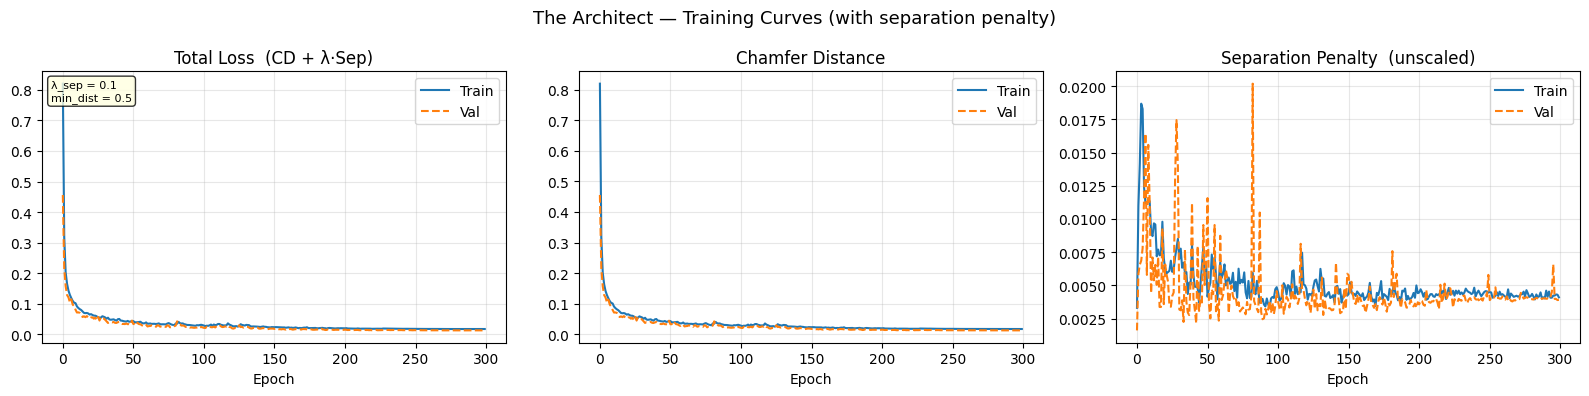


Post-training separation audit (val set, 100 random samples):
  Violating pairs : 266 / 16644  (1.60%)
  Target          : < 2% violation rate
  ✅ Separation constraint well satisfied


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, key, label in [
    (axes[0], 'total',   'Total Loss  (CD + λ·Sep)'),
    (axes[1], 'chamfer', 'Chamfer Distance'),
    (axes[2], 'sep',     'Separation Penalty  (unscaled)'),
]:
    ax.plot([e[key] for e in history['train']], label='Train', linewidth=1.5)
    ax.plot([e[key] for e in history['val']],   label='Val',   linewidth=1.5, linestyle='--')
    ax.set_title(label); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

# Annotate the lambda on the total-loss plot
axes[0].annotate(
    f'λ_sep = {SEP_LAMBDA}\nmin_dist = {MIN_PRED_DIST}',
    xy=(0.02, 0.97), xycoords='axes fraction',
    fontsize=8, va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)

plt.suptitle('The Architect — Training Curves (with separation penalty)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Quick post-training separation check ─────────────────────────────────────────
# How many predicted slot pairs in the val set violate MIN_PRED_DIST?
print("\nPost-training separation audit (val set, 100 random samples):")
_audit_samples = random.sample(val_dataset, min(100, len(val_dataset)))
_violations = 0
_total_pairs = 0
model.eval()
with torch.no_grad():
    for _d in _audit_samples:
        _d = _d.to(DEVICE)
        _out = model(
            x=_d.x, edge_index=_d.edge_index, edge_attr=_d.edge_attr,
            pos=_d.pos,
            formation_id=_d.formation_id.unsqueeze(0),
            swarm_cog=None, batch=None,
        )
        _pred = _out['local_slots'].cpu()
        _n    = _pred.size(0)
        for _i in range(_n):
            for _j in range(_i + 1, _n):
                _dist = (_pred[_i] - _pred[_j]).norm().item()
                _total_pairs += 1
                if _dist < MIN_PRED_DIST:
                    _violations += 1

_viol_pct = 100.0 * _violations / max(_total_pairs, 1)
print(f"  Violating pairs : {_violations} / {_total_pairs}  ({_viol_pct:.2f}%)")
print(f"  Target          : < 2% violation rate")
if _viol_pct < 2.0:
    print("  ✅ Separation constraint well satisfied")
elif _viol_pct < 5.0:
    print("  ⚠️  Some violations — consider increasing SEP_LAMBDA to 0.1")
else:
    print("  ❌ Too many violations — increase SEP_LAMBDA or train more epochs")


## 11. Qualitative Evaluation

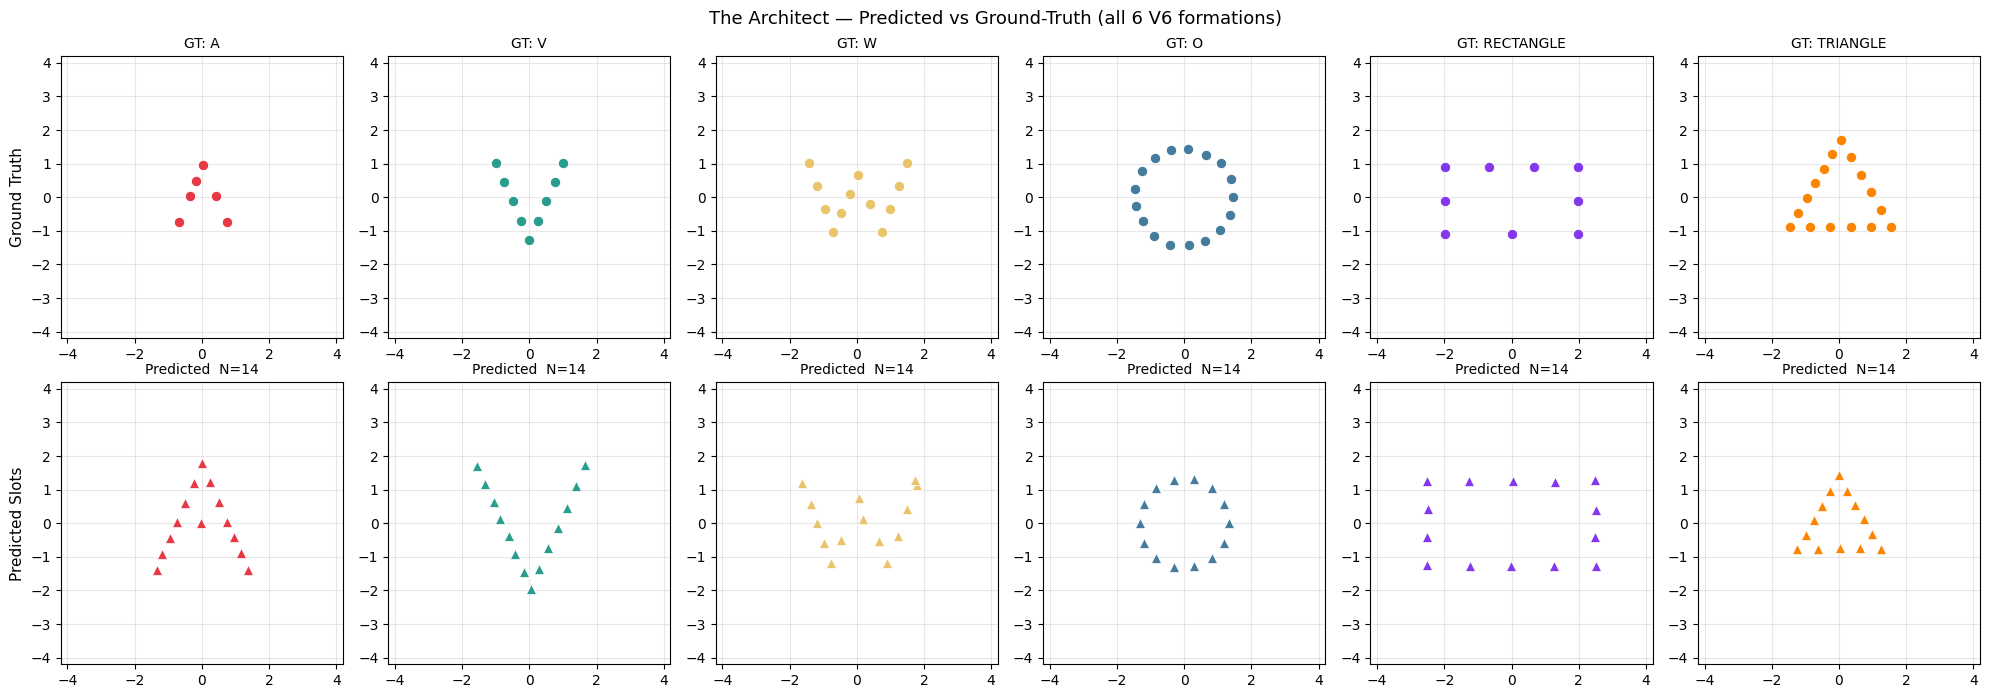

In [38]:
# Load best checkpoint
model.load_state_dict(torch.load("./model/architect_best_v10.pt", map_location=DEVICE))
model.eval()


@torch.no_grad()
def predict_formation(
    n: int,
    formation_id: int,
    swarm_cog: Tuple[float, float] = (0.0, 0.0),
) -> dict:
    """
    Full inference pipeline for The Architect.

    Args:
        n            : number of drones  (5 – 30)
        formation_id : desired shape ID  (0=A, 1=V, 2=W, 3=O, 4=Rectangle, 5=Triangle)
        swarm_cog    : (x, y) real-world centre-of-gravity of the swarm

    Returns:
        dict with 'displacement_vec', 'local_slots', 'global_slots'
    """
    # Clamp n to valid range
    n = max(N_DRONES_RANGE[0], min(N_DRONES_RANGE[1], n))

    emb_weights = model.formation_embedding.weight.detach()
    gt_dummy    = torch.zeros(n, 2)
    data        = build_pyg_graph(n, formation_id, emb_weights, gt_dummy)
    data        = data.to(DEVICE)

    cog_tensor = torch.tensor([[swarm_cog[0], swarm_cog[1]]], dtype=torch.float, device=DEVICE)

    out = model(
        x=data.x,
        edge_index=data.edge_index,
        edge_attr=data.edge_attr,
        pos=data.pos,
        formation_id=data.formation_id.unsqueeze(0),
        swarm_cog=cog_tensor,
        batch=None,
    )
    return {k: v.cpu() for k, v in out.items()}


# ── Plot predicted vs GT (one from dataset) for all 6 formations ─────────────────
N_TEST = 14   # a mid-range swarm size for the visual
_COLOURS = {0:'#E63946', 1:'#2A9D8F', 2:'#E9C46A', 3:'#457B9D', 4:'#8338EC', 5:'#FB8500'}

fig, axes = plt.subplots(2, NUM_FORMATIONS, figsize=(20, 7))

for fid in range(NUM_FORMATIONS):
    # Pull one GT sample from the val set that matches this formation
    _gt_sample = next((d for d in val_dataset if int(d.formation_id.item()) == fid), None)
    gt_pts = _gt_sample.y.numpy() if _gt_sample is not None else torch.zeros(N_TEST,2).numpy()

    result = predict_formation(N_TEST, fid)
    local  = result["local_slots"].numpy()
    col    = _COLOURS[fid]

    ax_gt = axes[0][fid]
    ax_pr = axes[1][fid]

    ax_gt.scatter(gt_pts[:, 0], gt_pts[:, 1], c=col, s=55, zorder=3,
                  edgecolors='white', linewidths=0.6)
    ax_gt.set_title(f"GT: {ID_TO_NAME[fid]}", fontsize=10)
    ax_gt.set_aspect("equal"); ax_gt.grid(True, alpha=0.3)
    ax_gt.set_xlim(-4.2, 4.2); ax_gt.set_ylim(-4.2, 4.2)

    ax_pr.scatter(local[:, 0], local[:, 1], c=col, s=55, marker="^", zorder=3,
                  edgecolors='white', linewidths=0.6)
    ax_pr.set_title(f"Predicted  N={N_TEST}", fontsize=10)
    ax_pr.set_aspect("equal"); ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim(-4.2, 4.2); ax_pr.set_ylim(-4.2, 4.2)

axes[0][0].set_ylabel("Ground Truth", fontsize=11)
axes[1][0].set_ylabel("Predicted Slots", fontsize=11)
plt.suptitle("The Architect — Predicted vs Ground-Truth (all 6 V6 formations)", fontsize=13)
plt.tight_layout()
plt.show()


## 12. Global-Slot Demo (with real CoG)

Simulate a swarm physically located at `(50, 30)` and show the shape teleported there.

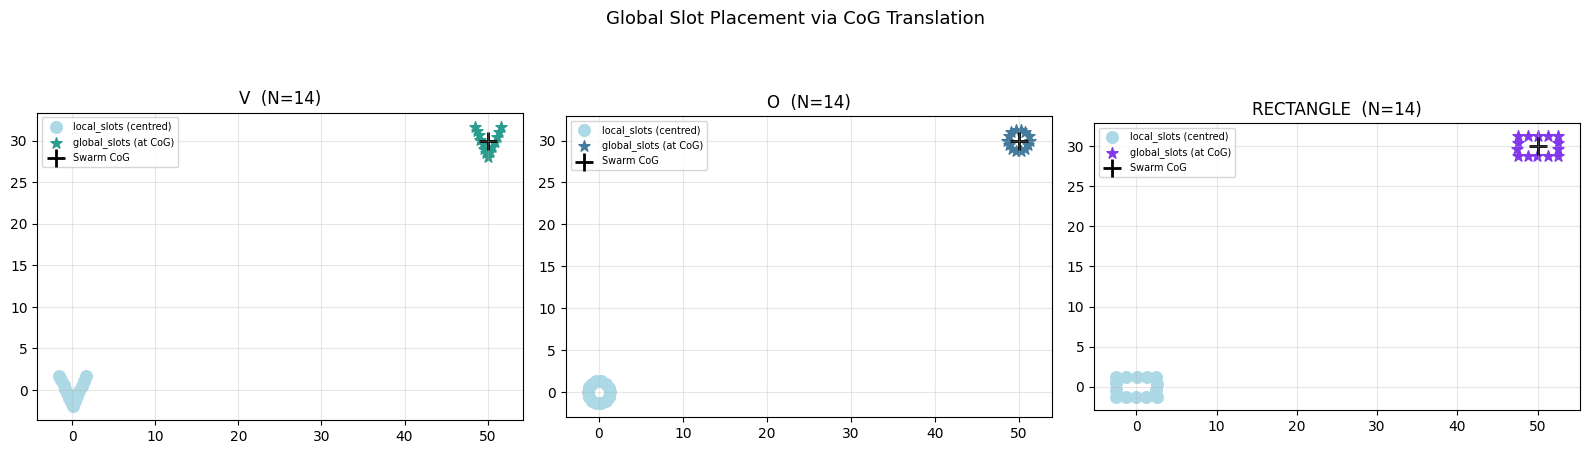

In [39]:
REAL_COG = (50.0, 30.0)   # metres
N_DEMO   = 14

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, fid in enumerate([FORMATION_IDS['V'], FORMATION_IDS['O'], FORMATION_IDS['RECTANGLE']]):
    ax = axes[i]
    result = predict_formation(N_DEMO, fid, swarm_cog=REAL_COG)
    local  = result["local_slots"].numpy()
    glob   = result["global_slots"].numpy()
    col    = _COLOURS[fid]

    ax.scatter(local[:, 0], local[:, 1], c='lightblue',  s=70, label="local_slots (centred)")
    ax.scatter(glob[:, 0],  glob[:, 1],  c=col,           s=70, marker="*", label="global_slots (at CoG)")
    ax.scatter(*REAL_COG, c="black", s=150, marker="+", linewidths=2, label="Swarm CoG")
    ax.set_title(f"{ID_TO_NAME[fid]}  (N={N_DEMO})")
    ax.legend(fontsize=7); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

plt.suptitle("Global Slot Placement via CoG Translation", fontsize=13)
plt.tight_layout()
plt.show()


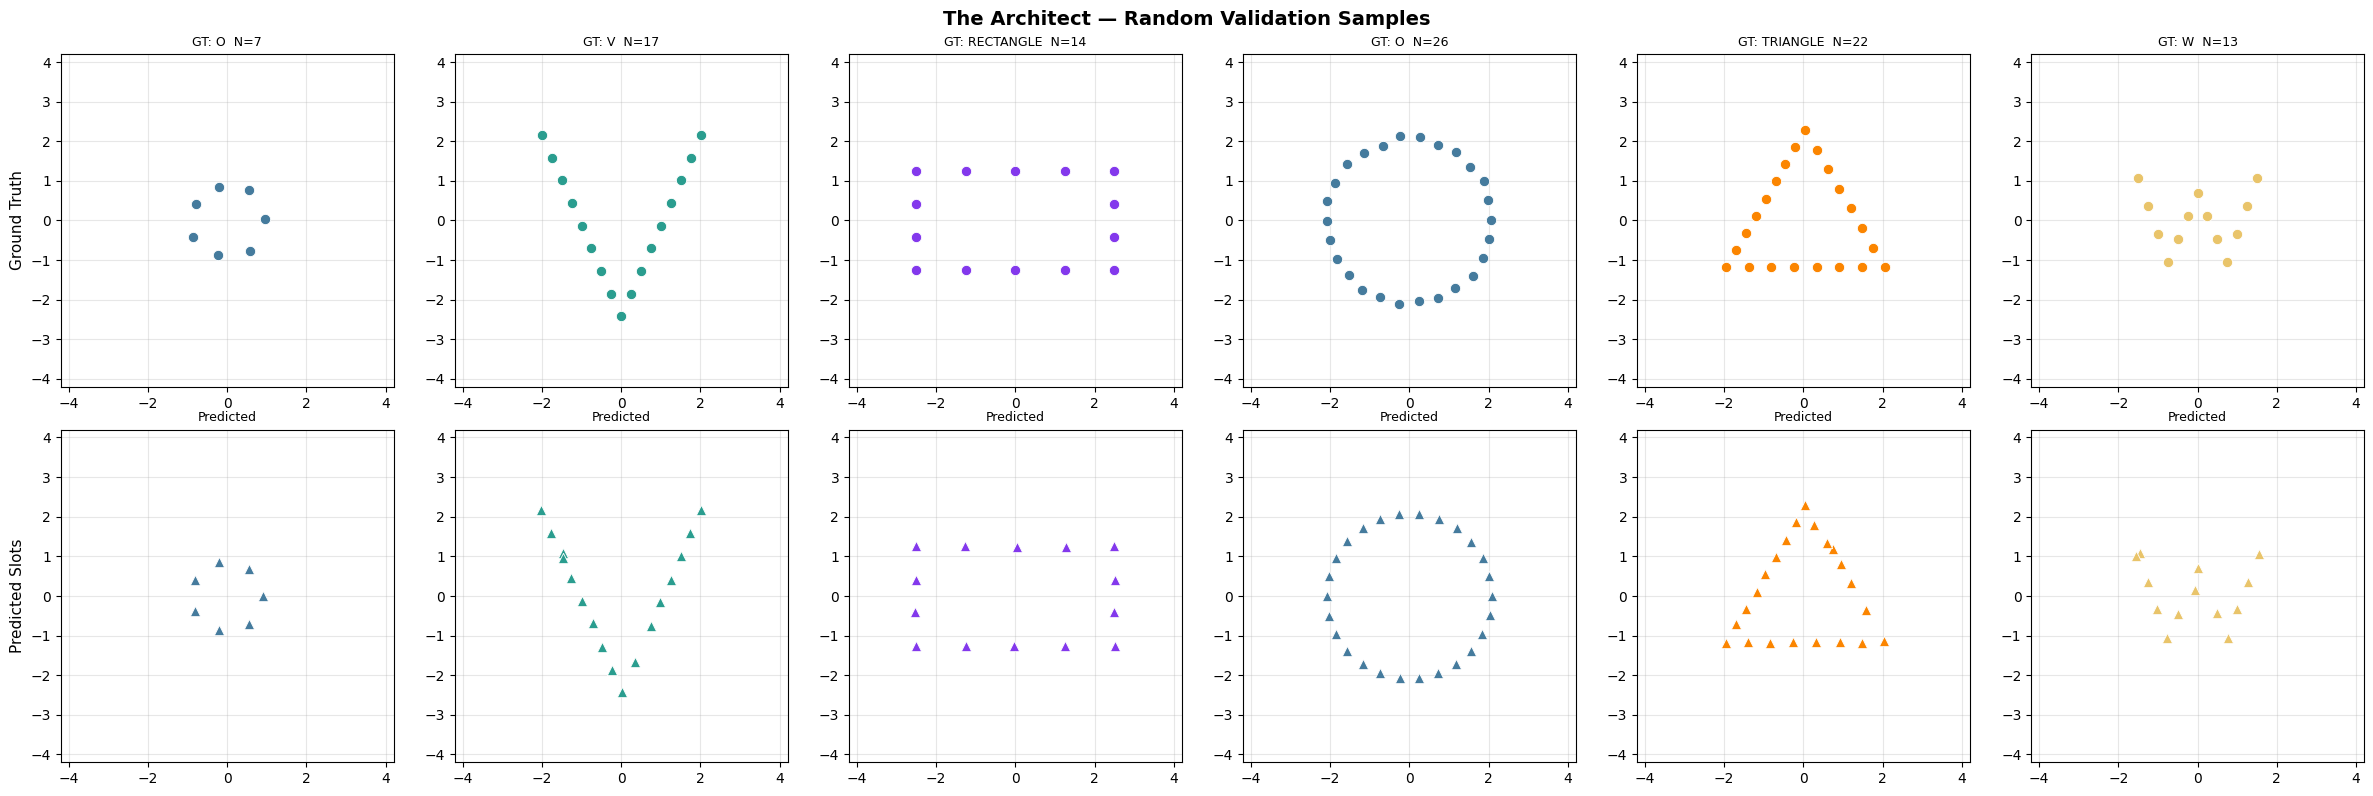

In [40]:
# ── Evaluate on random samples from the VALIDATION set ───────────────────────────
# Uses the actual formation_id stored in each Data object — no dummy IDs.

NUM_SAMPLES = 6
_samples    = random.sample(val_dataset, NUM_SAMPLES)

fig, axes = plt.subplots(2, NUM_SAMPLES, figsize=(4 * NUM_SAMPLES, 8))

for i, data in enumerate(_samples):
    data     = data.to(DEVICE)
    n_drones = int(data.n_drones.item())
    fid      = int(data.formation_id.item())
    col      = _COLOURS[fid]

    cog_tensor = torch.zeros((1, 2), dtype=torch.float, device=DEVICE)

    with torch.no_grad():
        out = model(
            x=data.x,
            edge_index=data.edge_index,
            edge_attr=data.edge_attr,
            pos=data.pos,
            formation_id=data.formation_id.unsqueeze(0),   # real fid, not dummy
            swarm_cog=cog_tensor,
            batch=None,
        )

    local_predicted = out["local_slots"].cpu().numpy()
    gt_pts          = data.y.cpu().numpy()

    ax_gt = axes[0][i]
    ax_pr = axes[1][i]

    ax_gt.scatter(gt_pts[:, 0], gt_pts[:, 1], c=col, s=55, zorder=3,
                  edgecolors='white', linewidths=0.6)
    ax_gt.set_title(f"GT: {ID_TO_NAME[fid]}  N={n_drones}", fontsize=9)
    ax_gt.set_aspect("equal"); ax_gt.grid(True, alpha=0.3)
    ax_gt.set_xlim(-4.2, 4.2); ax_gt.set_ylim(-4.2, 4.2)

    ax_pr.scatter(local_predicted[:, 0], local_predicted[:, 1], c=col,
                  s=55, marker="^", zorder=3, edgecolors='white', linewidths=0.6)
    ax_pr.set_title("Predicted", fontsize=9)
    ax_pr.set_aspect("equal"); ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim(-4.2, 4.2); ax_pr.set_ylim(-4.2, 4.2)

axes[0][0].set_ylabel("Ground Truth", fontsize=11)
axes[1][0].set_ylabel("Predicted Slots", fontsize=11)
plt.suptitle("The Architect — Random Validation Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


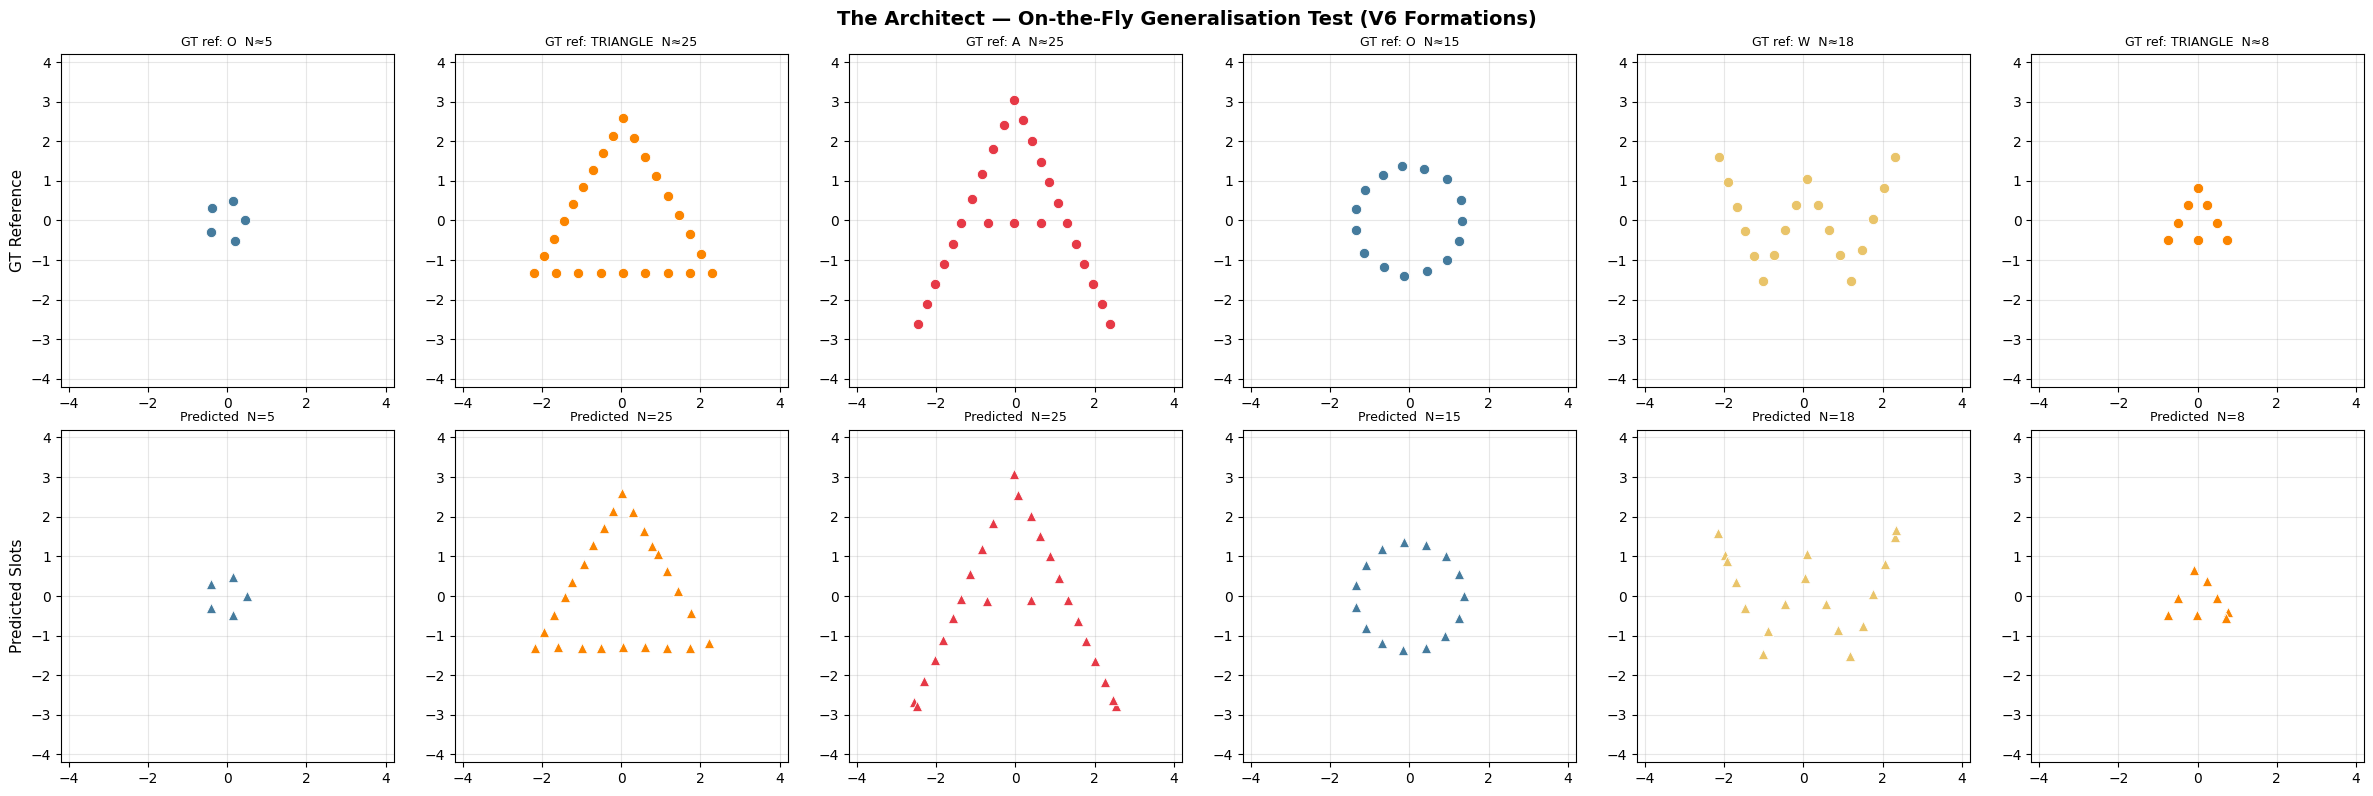

In [41]:
# ── On-the-fly generalisation test ───────────────────────────────────────────────
# Tests N and formation combinations that may not appear in the dataset.
# GT is pulled from the closest val-set sample (same fid, nearest N).

NUM_SAMPLES = 6
fig, axes = plt.subplots(2, NUM_SAMPLES, figsize=(4 * NUM_SAMPLES, 8))

for i in range(NUM_SAMPLES):
    n_test = random.randint(*N_DRONES_RANGE)
    fid    = random.randint(0, NUM_FORMATIONS - 1)
    col    = _COLOURS[fid]

    # Nearest val sample for GT reference
    _candidates = [d for d in val_dataset if int(d.formation_id.item()) == fid]
    _nearest    = min(_candidates, key=lambda d: abs(int(d.n_drones.item()) - n_test),
                      default=None)
    gt_pts = _nearest.y.numpy() if _nearest else np.zeros((n_test, 2))

    result          = predict_formation(n_test, fid)
    local_predicted = result["local_slots"].numpy()

    ax_gt = axes[0][i]
    ax_pr = axes[1][i]

    ax_gt.scatter(gt_pts[:, 0], gt_pts[:, 1], c=col, s=55, zorder=3,
                  edgecolors='white', linewidths=0.6)
    ax_gt.set_title(f"GT ref: {ID_TO_NAME[fid]}  N≈{n_test}", fontsize=9)
    ax_gt.set_aspect("equal"); ax_gt.grid(True, alpha=0.3)
    ax_gt.set_xlim(-4.2, 4.2); ax_gt.set_ylim(-4.2, 4.2)

    ax_pr.scatter(local_predicted[:, 0], local_predicted[:, 1], c=col,
                  s=55, marker="^", zorder=3, edgecolors='white', linewidths=0.6)
    ax_pr.set_title(f"Predicted  N={n_test}", fontsize=9)
    ax_pr.set_aspect("equal"); ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim(-4.2, 4.2); ax_pr.set_ylim(-4.2, 4.2)

axes[0][0].set_ylabel("GT Reference", fontsize=11)
axes[1][0].set_ylabel("Predicted Slots", fontsize=11)
plt.suptitle("The Architect — On-the-Fly Generalisation Test (V6 Formations)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

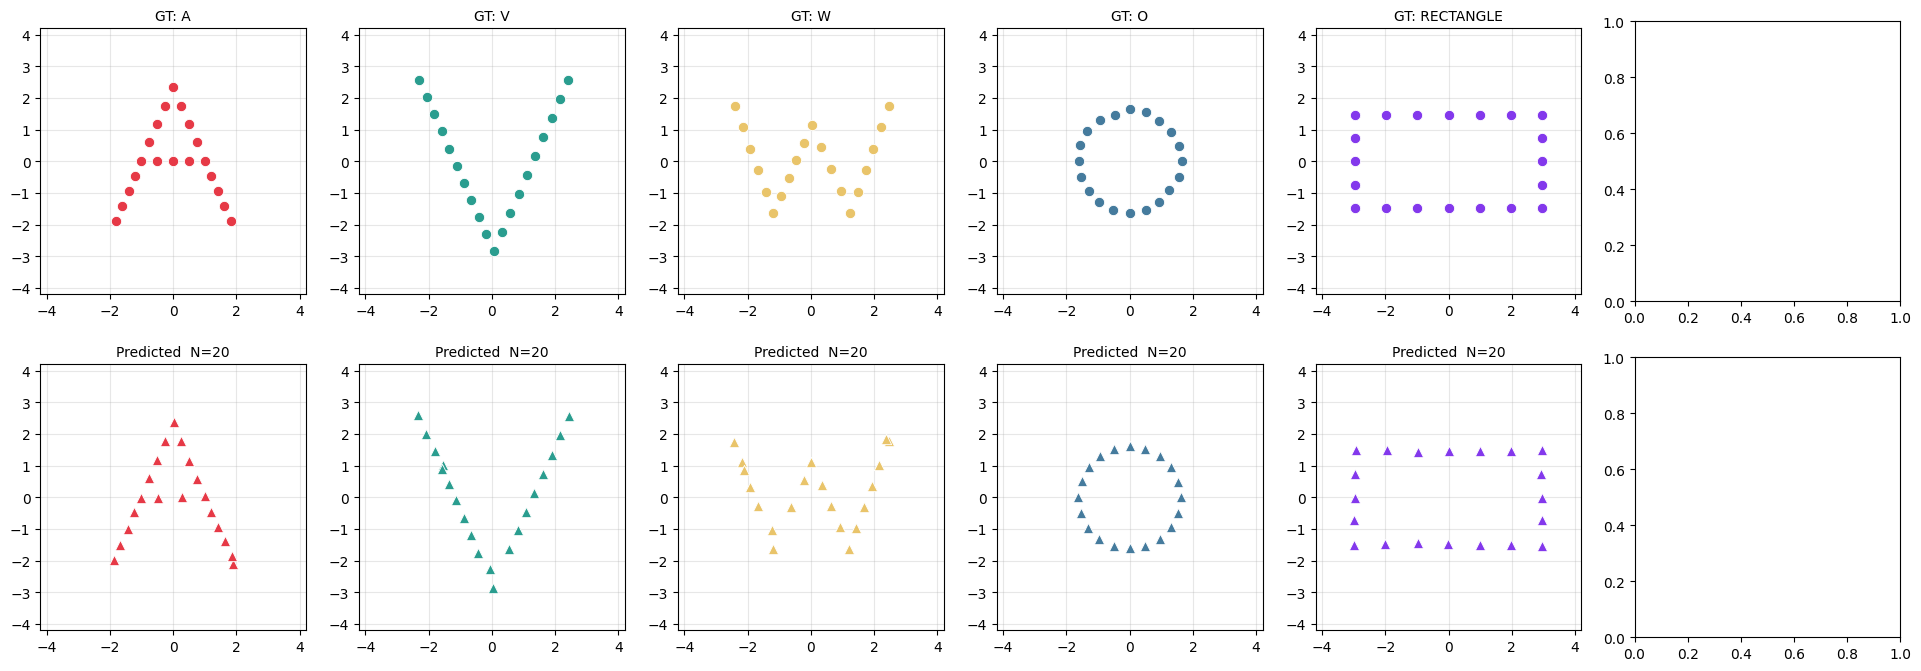

In [42]:
# ── Specific formation test ───────────────────────────────────────────────────────
# Test one sample per formation at a fixed N to compare shape quality side-by-side.

N_FIXED = 20   # must be in [5, 30]

fig, axes = plt.subplots(2, NUM_FORMATIONS, figsize=(4 * NUM_FORMATIONS, 8))

for fid in range(NUM_FORMATIONS):
    col = _COLOURS[fid]

    # GT: closest val sample
    _cands  = [d for d in val_dataset if int(d.formation_id.item()) == fid]
    _near   = min(_cands, key=lambda d: abs(int(d.n_drones.item()) - N_FIXED), default=None)
    gt_pts  = _near.y.numpy() if _near else np.zeros((N_FIXED, 2))

    result          = predict_formation(N_FIXED, fid)
    local_predicted = result["local_slots"].numpy()

    ax_gt = axes[0][fid]
    ax_pr = axes[1][fid]

    ax_gt.scatter(gt_pts[:, 0], gt_pts[:, 1], c=col, s=55, zorder=3,
                  edgecolors='white', linewidths=0.6)
    ax_gt.set_title(f"GT: {ID_TO_NAME[fid]}", fontsize=10)
    ax_gt.set_aspect("equal"); ax_gt.grid(True, alpha=0.3)
    ax_gt.set_xlim(-4.2, 4.2); ax_gt.set_ylim(-4.2, 4.2)

    ax_pr.scatter(local_predicted[:, 0], local_predicted[:, 1], c=col,
                  s=55, marker="^", zorder=3, edgecolors='white', linewidths=0.6)
    ax_pr.set_title(f"Predicted  N={N_FIXED}", fontsize=10)
    ax_pr.set_aspect("equal"); ax_pr.grid(True, alpha=0.3)
    ax_pr.set_xlim(-4.2, 4.2); ax_pr.set_ylim(-4.2, 4.2)

axes[0][0].set_ylabel("Ground Truth", fontsize=11)
axes[1][0].set_ylabel("Predicted Slots", fontsize=11)
plt.suptitle(f"The Architect — All 6 V6 Formations  (N={N_FIXED})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SLOT COLLISION CHECKER
# ─────────────────────────────────────────────────────────────────────────────
#
# check_slot_collisions(slots, min_dist, label)
#     → prints a detailed collision report for one prediction
#
# audit_all_formations(n_values, min_dist)
#     → sweeps every formation × every N and produces a summary table + heatmap
#
# Usage after training:
#     check_slot_collisions(predict_formation(20, FORMATION_IDS['W'])['local_slots'])
#     audit_all_formations()

import itertools

def check_slot_collisions(
    slots:    torch.Tensor,
    min_dist: float = MIN_PRED_DIST,
    label:    str   = "",
    verbose:  bool  = True,
) -> dict:
    """
    Inspect one set of predicted slots for pairwise collisions.

    Args
    ────
    slots    : (N, 2) tensor of predicted slot positions
    min_dist : minimum allowed centre-to-centre distance
    label    : string shown in the printed report
    verbose  : if True, prints the full report; if False, silent

    Returns
    ───────
    dict with keys:
        'n'             : swarm size
        'n_violations'  : number of violating pairs
        'min_dist_found': smallest pairwise distance found
        'violations'    : list of (i, j, distance) for each violating pair
        'ok'            : True if no violations
    """
    slots = slots.detach().cpu().float()
    n     = slots.size(0)

    # All-pairs distances — upper triangle only (avoid double-counting)
    violations = []
    min_d_seen = float('inf')

    for i in range(n):
        for j in range(i + 1, n):
            d = (slots[i] - slots[j]).norm().item()
            if d < min_d_seen:
                min_d_seen = d
            if d < min_dist:
                violations.append((i, j, d))

    result = {
        'n'             : n,
        'n_violations'  : len(violations),
        'min_dist_found': min_d_seen,
        'violations'    : violations,
        'ok'            : len(violations) == 0,
    }

    if verbose:
        header = f"Slot Collision Report{f' — {label}' if label else ''}"
        print(f"\n{'─'*55}")
        print(f"  {header}")
        print(f"{'─'*55}")
        print(f"  N drones       : {n}")
        print(f"  MIN_PRED_DIST  : {min_dist}")
        print(f"  Min dist found : {min_d_seen:.5f}  "
              f"({'✅ OK' if min_d_seen >= min_dist else '❌ BELOW THRESHOLD'})")
        print(f"  Violations     : {len(violations)}")
        if violations:
            print()
            print(f"  {'Pair':>10}  {'Distance':>10}  {'Gap':>10}  Status")
            print(f"  {'-'*10}  {'-'*10}  {'-'*10}  ------")
            for i, j, d in sorted(violations, key=lambda x: x[2]):
                gap = d - min_dist
                print(f"  ({i:>3},{j:>3})    {d:>10.5f}  {gap:>+10.5f}  ❌")
        else:
            print(f"  ✅ No collisions detected")
        print(f"{'─'*55}\n")

    return result


def audit_all_formations(
    n_values:   list = None,
    min_dist:   float = MIN_PRED_DIST,
    plot:       bool  = True,
    print_table:bool  = True,
) -> dict:
    """
    Sweep every (formation, N) combination and report collision statistics.

    For each combination:
        - Runs predict_formation(n, fid)
        - Calls check_slot_collisions (silent)
        - Records violation count and minimum distance

    Args
    ────
    n_values    : list of swarm sizes to test (default: [5,8,10,12,15,18,20,23,25,28,30])
    min_dist    : collision threshold
    plot        : if True, show a heatmap of min distances per (formation, N)
    print_table : if True, print a summary table

    Returns
    ───────
    dict: results[formation_name][n] = check_slot_collisions result dict
    """
    if n_values is None:
        n_values = [5, 8, 10, 12, 15, 18, 20, 23, 25, 28, 30]

    model.eval()
    results = {ID_TO_NAME[fid]: {} for fid in range(NUM_FORMATIONS)}

    for fid in range(NUM_FORMATIONS):
        fname = ID_TO_NAME[fid]
        for n in n_values:
            pred   = predict_formation(n, fid)
            slots  = pred['local_slots']
            result = check_slot_collisions(slots, min_dist=min_dist,
                                           label=f"{fname} N={n}", verbose=False)
            results[fname][n] = result

    # ── Summary table ─────────────────────────────────────────────────────────
    if print_table:
        col_w = 8
        header = f"  {'Formation':<12}" + "".join(f"{n:>{col_w}}" for n in n_values)
        print("\n" + "="*len(header))
        print("  MIN PAIRWISE DISTANCE  (✅ ≥ threshold  |  ❌ < threshold)")
        print(f"  threshold = {min_dist}")
        print("="*len(header))
        print(header)
        print("  " + "-"*(len(header)-2))
        for fname in results:
            row = f"  {fname:<12}"
            for n in n_values:
                r   = results[fname][n]
                d   = r['min_dist_found']
                ok  = r['ok']
                tag = f"{d:.3f}" if ok else f"{d:.3f}❌"
                row += f"{tag:>{col_w}}"
            print(row)
        print("="*len(header))

        # Overall summary
        all_viols = sum(
            results[fname][n]['n_violations']
            for fname in results for n in n_values
        )
        total_tests = NUM_FORMATIONS * len(n_values)
        ok_tests    = sum(
            1 for fname in results for n in n_values if results[fname][n]['ok']
        )
        print(f"\n  Total tests   : {total_tests}")
        print(f"  Clean (0 viols): {ok_tests}  ({100*ok_tests/total_tests:.1f}%)")
        print(f"  Total violations across all tests: {all_viols}")

        # Flag worst offenders
        worst = sorted(
            [(fname, n, results[fname][n]['min_dist_found'])
             for fname in results for n in n_values],
            key=lambda x: x[2]
        )[:5]
        if worst and worst[0][2] < min_dist:
            print(f"\n  Worst cases (smallest min distance):")
            for fname, n, d in worst:
                if d < min_dist:
                    nv = results[fname][n]['n_violations']
                    print(f"    {fname:<12}  N={n:<3}  min_dist={d:.5f}  violations={nv}")

    # ── Heatmap ───────────────────────────────────────────────────────────────
    if plot:
        import numpy as np
        formation_names = [ID_TO_NAME[fid] for fid in range(NUM_FORMATIONS)]
        mat = np.array([
            [results[fname][n]['min_dist_found'] for n in n_values]
            for fname in formation_names
        ])

        fig, axes = plt.subplots(1, 2, figsize=(16, 4))

        # Left: min distance heatmap
        ax = axes[0]
        im = ax.imshow(mat, aspect='auto', cmap='RdYlGn',
                       vmin=0, vmax=min_dist * 3)
        ax.set_xticks(range(len(n_values))); ax.set_xticklabels(n_values)
        ax.set_yticks(range(len(formation_names))); ax.set_yticklabels(formation_names)
        ax.set_xlabel("N (swarm size)"); ax.set_title("Min Pairwise Distance per (Formation, N)")
        plt.colorbar(im, ax=ax, label="min dist")
        # Draw threshold line annotation
        ax.axhline(-0.5, color='red', lw=0.5, alpha=0.3)
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val   = mat[i, j]
                color = 'white' if val < min_dist * 1.5 else 'black'
                flag  = '❌' if val < min_dist else ''
                ax.text(j, i, f"{val:.2f}{flag}", ha='center', va='center',
                        fontsize=7, color=color)

        # Right: violation count heatmap
        ax = axes[1]
        viol_mat = np.array([
            [results[fname][n]['n_violations'] for n in n_values]
            for fname in formation_names
        ])
        im2 = ax.imshow(viol_mat, aspect='auto', cmap='Reds', vmin=0)
        ax.set_xticks(range(len(n_values))); ax.set_xticklabels(n_values)
        ax.set_yticks(range(len(formation_names))); ax.set_yticklabels(formation_names)
        ax.set_xlabel("N (swarm size)"); ax.set_title("Violation Count per (Formation, N)")
        plt.colorbar(im2, ax=ax, label="# violations")
        for i in range(viol_mat.shape[0]):
            for j in range(viol_mat.shape[1]):
                v = int(viol_mat[i, j])
                ax.text(j, i, str(v) if v > 0 else '✓',
                        ha='center', va='center', fontsize=8,
                        color='white' if v > 2 else 'black')

        plt.suptitle(f"Slot Collision Audit  |  threshold = {min_dist}", fontsize=12)
        plt.tight_layout()
        plt.show()

    return results


# ── Quick usage examples ──────────────────────────────────────────────────────
print("Functions defined:")
print("  check_slot_collisions(slots, min_dist, label, verbose)")
print("  audit_all_formations(n_values, min_dist, plot, print_table)")
print()
print("Quick examples:")
print("  # Check one prediction:")
print("  r = check_slot_collisions(predict_formation(20, FORMATION_IDS['W'])['local_slots'])")
print()
print("  # Full audit of every formation × N combination:")
print("  results = audit_all_formations()")
print()
print("  # Check a specific N range where you suspect problems:")
print("  audit_all_formations(n_values=[15, 18, 20, 22, 25], plot=True)")


Functions defined:
  check_slot_collisions(slots, min_dist, label, verbose)
  audit_all_formations(n_values, min_dist, plot, print_table)

Quick examples:
  # Check one prediction:
  r = check_slot_collisions(predict_formation(20, FORMATION_IDS['W'])['local_slots'])

  # Full audit of every formation × N combination:
  results = audit_all_formations()

  # Check a specific N range where you suspect problems:
  audit_all_formations(n_values=[15, 18, 20, 22, 25], plot=True)


=== W formation, N=20 ===

───────────────────────────────────────────────────────
  Slot Collision Report — W  N=20
───────────────────────────────────────────────────────
  N drones       : 20
  MIN_PRED_DIST  : 0.3
  Min dist found : 0.17672  (❌ BELOW THRESHOLD)
  Violations     : 1

        Pair    Distance         Gap  Status
  ----------  ----------  ----------  ------
  ( 10, 11)       0.17672    -0.12328  ❌
───────────────────────────────────────────────────────

=== Full audit ===

  MIN PAIRWISE DISTANCE  (✅ ≥ threshold  |  ❌ < threshold)
  threshold = 0.3
  Formation          5       6       7       9       8      10      12      15      18      20      23      25      28      30
  ----------------------------------------------------------------------------------------------------------------------------
  A              0.469   0.491   0.497   0.483   0.485   0.453  0.157❌   0.473   0.507  0.108❌  0.099❌  0.175❌  0.126❌  0.113❌
  V              0.492   0.511   0.498   0.516

C:\Users\ASUS\AppData\Local\Temp\ipykernel_25616\2525629129.py:224: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ASUS\anaconda3\envs\torch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


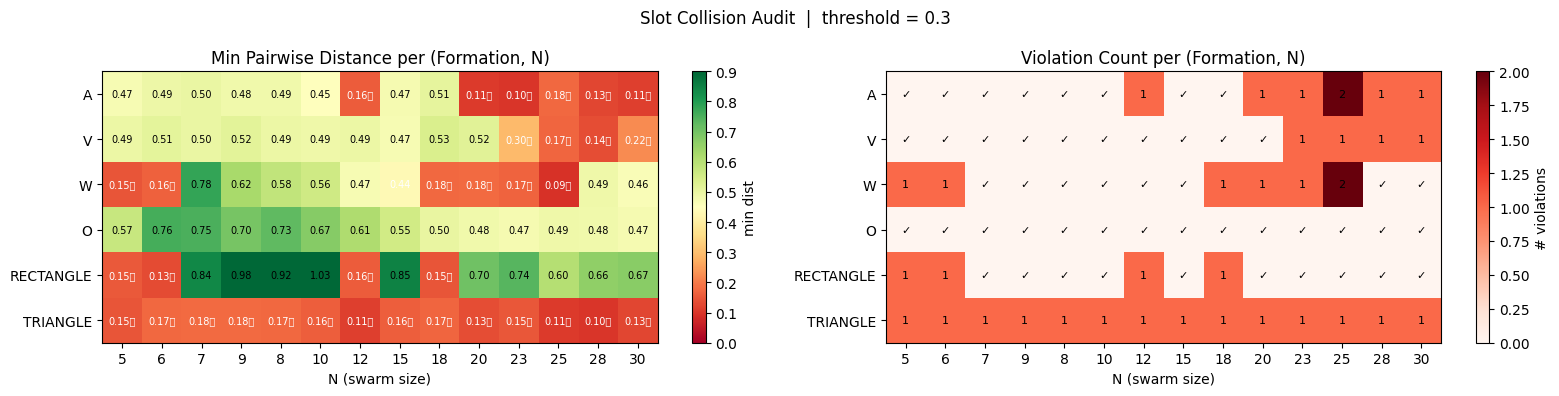

In [ ]:
# ── Run the audit immediately ─────────────────────────────────────────────────

# 1. Single formation deep-dive (W at N=20 — the known problem case)
print("=== W formation, N=20 ===")
r = check_slot_collisions(
    slots = predict_formation(20, FORMATION_IDS['W'])['local_slots'],
    label = "W  N=20",
)

# 2. Full sweep — find every (formation, N) that still has collisions
print("=== Full audit ===")
results = audit_all_formations(
    n_values    = [5,6,7,9, 8, 10, 12, 15, 18, 20, 23, 25, 28, 30],
    min_dist    = MIN_PRED_DIST,
    plot        = True,
    print_table = True,
)


## 13. Export for Notebook 2

Save the model weights and a utility function so *The Negotiator* can load them.

In [ ]:
# ── Save final model for cross-notebook use ───────────────────────────────────────
SAVE_PATH = "./model/architect_final_v10.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "num_formations":    NUM_FORMATIONS,
            "formation_ids":     FORMATION_IDS,
            "id_to_name":        ID_TO_NAME,
            "formation_emb_dim": FORMATION_EMB_DIM,
            "node_feat_dim":     NODE_FEAT_DIM,
            "hidden_dim":        HIDDEN_DIM,
            "num_heads":         NUM_GAT_HEADS,
            "num_layers":        NUM_GNN_LAYERS,
            "n_drones_range":    N_DRONES_RANGE,
            "seed_circle_radius":SEED_CIRCLE_RADIUS,
            "dataset_path":      DATASET_PATH,
        },
    },
    SAVE_PATH,
)
print(f"✅ Model saved to {SAVE_PATH}")


@torch.no_grad()
def get_global_slots(
    n: int,
    formation_id: int,
    swarm_cog: Tuple[float, float],
    device: torch.device = torch.device("cpu"),
) -> torch.Tensor:
    """
    Public API: ask The Architect for `n` global slot positions.

    Args:
        n            : number of drones  (5–30)
        formation_id : 0=A, 1=V, 2=W, 3=O, 4=Rectangle, 5=Triangle
        swarm_cog    : (x, y) real-world swarm centre-of-gravity

    Returns:
        global_slots  (n, 2) float tensor on CPU
    """
    result = predict_formation(n, formation_id, swarm_cog=swarm_cog)
    return result["global_slots"]


# Quick smoke-test
slots = get_global_slots(12, FORMATION_IDS['V'], swarm_cog=(100.0, 200.0))
print(f"global_slots shape: {slots.shape}")
print(f"CoG of returned slots: {slots.mean(dim=0).numpy().round(2)}")


✅ Model saved to ./model/architect_final_v10.pt
global_slots shape: torch.Size([12, 2])
CoG of returned slots: [100.   200.01]


---
### Summary

| Component | Details |
|---|---|
| **Data source** | `architect_dataset_10k_V10.pt` — V10 data generation pipeline |
| **Formations** | A (0), V (1), W (2), O (3), Rectangle (4), Triangle (5) |
| **Swarm sizes** | N = 5 – 30 (scale-adaptive, corners-first, collision-safe) |
| **Seed graph** | N nodes on unit circle → k-NN edges (k=min(5, n-1)) |
| **Node features** | seed_pos (2D) ∥ formation_embedding (16D) ∥ n_norm (1D) ∥ node_idx_norm (1D) → 20D |
| **Network** | Linear proj → 3 × GATv2 (4 heads, 64-D) + LayerNorm + residual |
| **Output** | displacement_vec (2D) per node |
| **Loss** | Chamfer Distance + λ·Separation Penalty (order-invariant) |
| **Translation** | `global_slots = local_slots + swarm_CoG` |

The saved model at `./model/architect_final_v10.pt` is ready to be loaded by **Notebook 2 — The Negotiator**.
